In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib.request

In [2]:
def load_gray_from_url(url):
    response = urllib.request.urlopen(url)
    data = np.asarray(bytearray(response.read()), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_GRAYSCALE)
    return img

In [3]:
def histogram_numpy(img):
    hist = np.zeros(256, dtype=np.int64)
    flat = img.ravel()
    for value in flat:
        hist[value] += 1
    return hist

In [4]:
def cdf_numpy(hist):
    return np.cumsum(hist)

In [5]:
def equalize_hist_numpy(img):
    hist = histogram_numpy(img)
    cdf = cdf_numpy(hist)

    cdf_nonzero = cdf[cdf > 0]
    cdf_min = cdf_nonzero[0]
    total_pixels = img.size

    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)

    result = lut[img]
    return result, hist, cdf, lut

In [6]:
url = "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Findiecatorhome.files.wordpress.com%2F2023%2F08%2Flinus-e1692337608336.jpg%3Fw%3D1024&f=1&nofb=1&ipt=c2cc0a8a5b62f13dd45d19f721fff3f4c5c3fcd015f7dfe11f998a87b322fc7d"
img = load_gray_from_url(url)

equalized_numpy, hist_numpy, cdf_vals, lut = equalize_hist_numpy(img)
equalized_cv = cv2.equalizeHist(img)

hist_eq_numpy = histogram_numpy(equalized_numpy)
hist_eq_cv = histogram_numpy(equalized_cv)

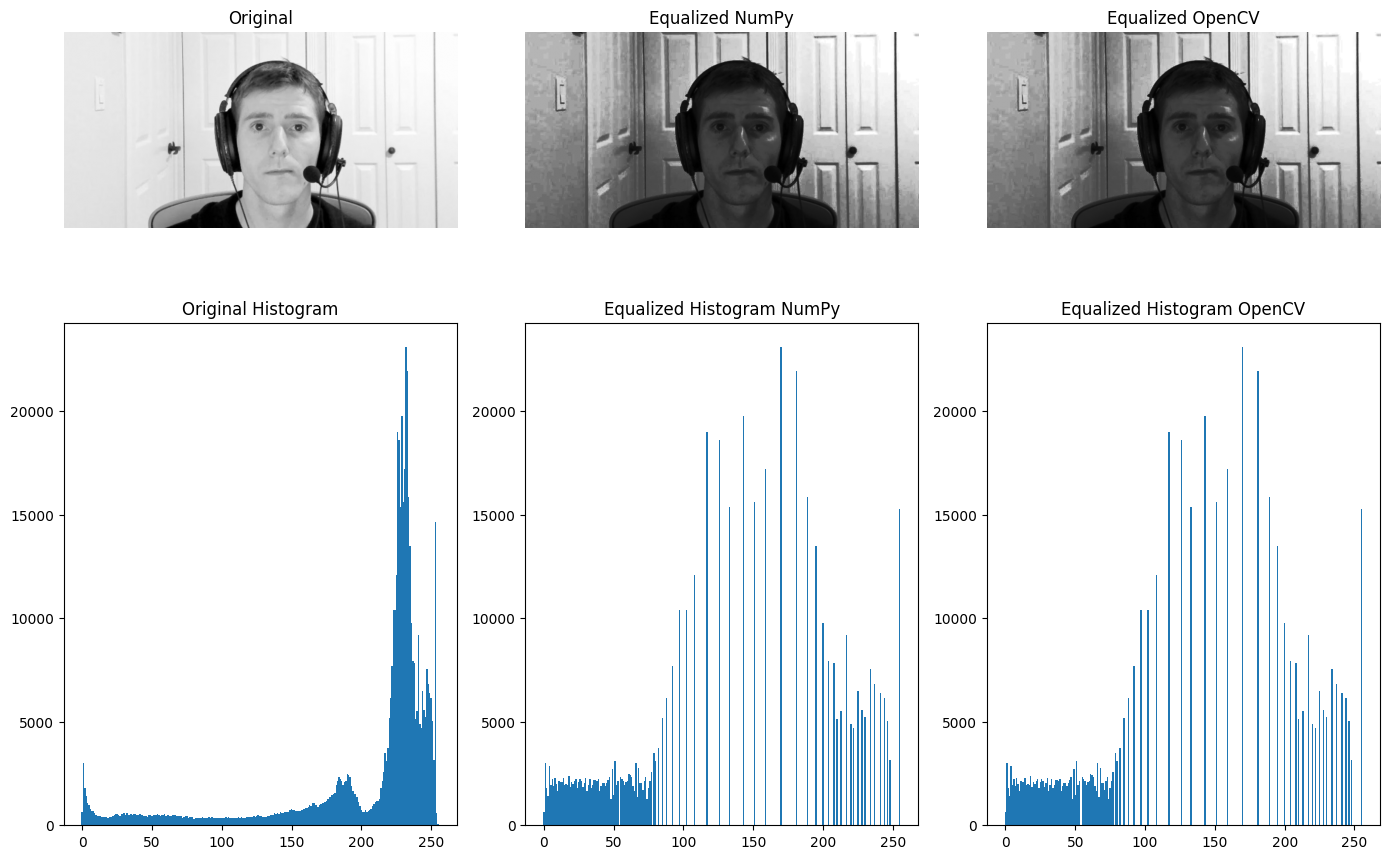

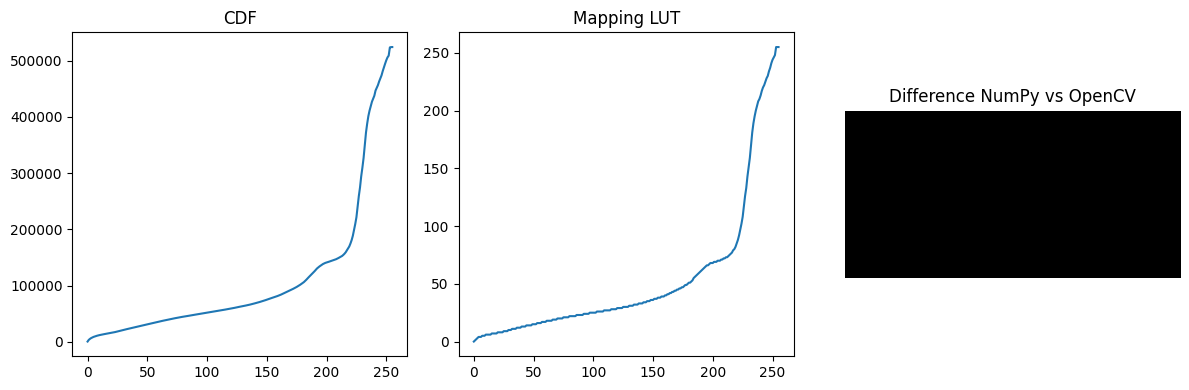

In [7]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(equalized_numpy, cmap="gray")
plt.title("Equalized NumPy")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(equalized_cv, cmap="gray")
plt.title("Equalized OpenCV")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.bar(np.arange(256), hist_numpy, width=1.0)
plt.title("Original Histogram")

plt.subplot(2, 3, 5)
plt.bar(np.arange(256), hist_eq_numpy, width=1.0)
plt.title("Equalized Histogram NumPy")

plt.subplot(2, 3, 6)
plt.bar(np.arange(256), hist_eq_cv, width=1.0)
plt.title("Equalized Histogram OpenCV")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(cdf_vals)
plt.title("CDF")

plt.subplot(1, 3, 2)
plt.plot(lut)
plt.title("Mapping LUT")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(equalized_numpy.astype(np.int16) - equalized_cv.astype(np.int16)).astype(np.uint8), cmap="gray")
plt.title("Difference NumPy vs OpenCV")
plt.axis("off")

plt.tight_layout()
plt.show()